# MULTIPLE LINEAR REGRESSION

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("ToyotaCorolla - MLR.csv")
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [3]:
df.shape

(1436, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [5]:
df.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


In [6]:
df.isnull().sum()

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

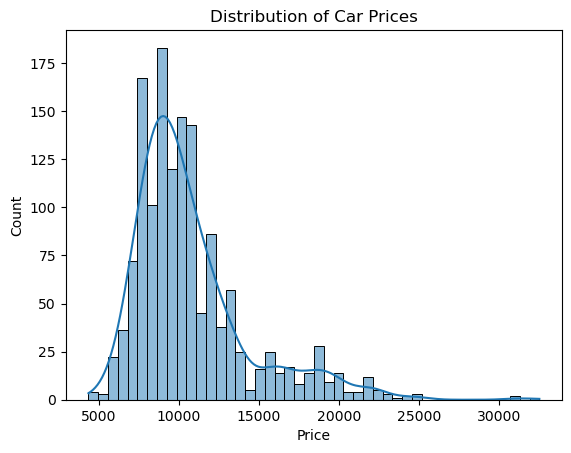

In [9]:
sns.histplot(df['Price'], kde=True)
plt.title("Distribution of Car Prices")
plt.show()

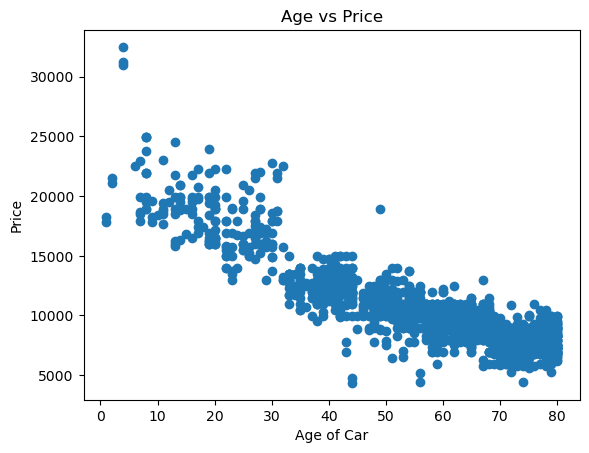

In [10]:
plt.scatter(df['Age_08_04'], df['Price'])
plt.xlabel("Age of Car")
plt.ylabel("Price")
plt.title("Age vs Price")
plt.show()

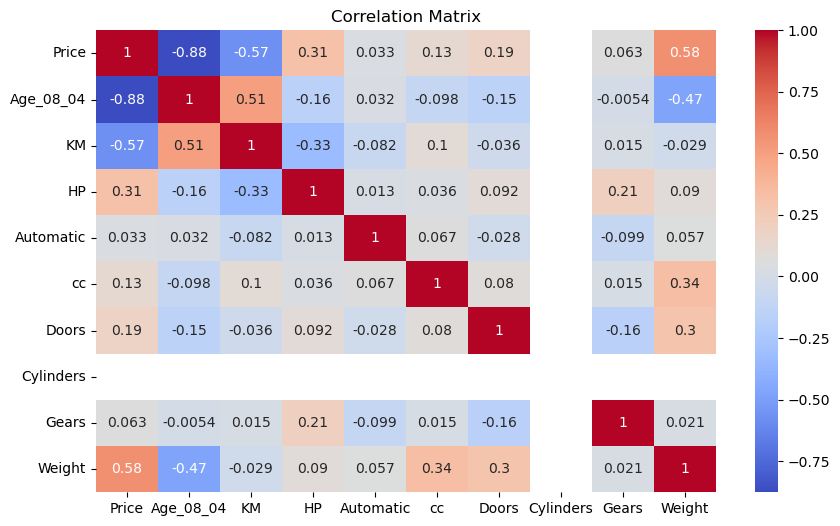

In [16]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

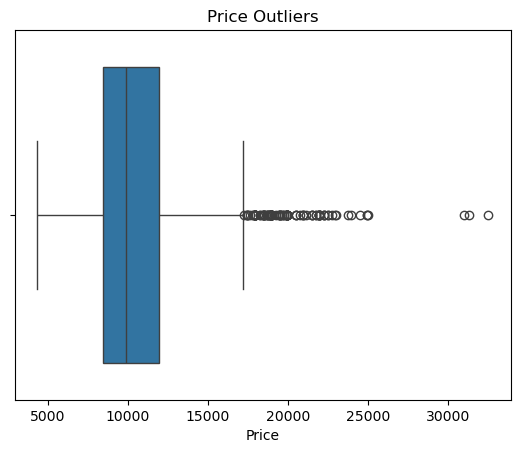

In [12]:
sns.boxplot(x=df['Price'])
plt.title("Price Outliers")
plt.show()

In [13]:
df = pd.get_dummies(df, columns=['Fuel_Type'], drop_first=True)

In [14]:
X = df.drop('Price', axis=1)
y = df['Price']

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42)

In [17]:
from sklearn.model_selection import train_test_split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1148, 11)
(288, 11)
(1148,)
(288,)


In [28]:
#  model 1 linear regression
from sklearn.linear_model import LinearRegression

model1 = LinearRegression()

model1.fit(X_train, y_train)

y_pred1 = model1.predict(X_test)

In [29]:
coeff1 = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model1.coef_
})

print(coeff1)

             Feature   Coefficient
0          Age_08_04 -1.208305e+02
1                 KM -1.623141e-02
2                 HP  1.403948e+01
3          Automatic  1.488309e+02
4                 cc -3.037219e-02
5              Doors -6.031097e+01
6          Cylinders -8.242296e-13
7              Gears  5.516007e+02
8             Weight  2.588496e+01
9   Fuel_Type_Diesel -6.854876e+01
10  Fuel_Type_Petrol  1.370809e+03


In [30]:
#Model 2 — Ridge Regression
from sklearn.linear_model import Ridge

model2 = Ridge(alpha=1.0)

model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)

In [31]:
coeff2 = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model2.coef_
})

print(coeff2)

             Feature  Coefficient
0          Age_08_04  -120.779659
1                 KM    -0.016324
2                 HP    14.141834
3          Automatic   146.907470
4                 cc    -0.030509
5              Doors   -59.905791
6          Cylinders     0.000000
7              Gears   542.272328
8             Weight    25.821019
9   Fuel_Type_Diesel  -128.813072
10  Fuel_Type_Petrol  1294.949826


In [32]:
#Model 3 — Lasso Regression
from sklearn.linear_model import Lasso

model3 = Lasso(alpha=1.0)

model3.fit(X_train, y_train)

y_pred3 = model3.predict(X_test)

In [33]:
coeff3 = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model3.coef_
})

print(coeff3)

             Feature  Coefficient
0          Age_08_04  -120.798032
1                 KM    -0.016326
2                 HP    14.559220
3          Automatic   133.401454
4                 cc    -0.032399
5              Doors   -58.673161
6          Cylinders     0.000000
7              Gears   522.177477
8             Weight    25.721963
9   Fuel_Type_Diesel   -32.310126
10  Fuel_Type_Petrol  1364.391707


In [34]:
from sklearn.metrics import r2_score

print("Linear Regression R2:", r2_score(y_test, y_pred1))
print("Ridge Regression R2:", r2_score(y_test, y_pred2))
print("Lasso Regression R2:", r2_score(y_test, y_pred3))

Linear Regression R2: 0.8348888040611082
Ridge Regression R2: 0.8351359377712335
Lasso Regression R2: 0.8354626403967389


In [35]:
y_pred1 = model1.predict(X_test)   # Linear Regression
y_pred2 = model2.predict(X_test)   # Ridge Regression
y_pred3 = model3.predict(X_test)   # Lasso Regression

In [36]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

In [37]:
print("Linear Regression R2:", r2_score(y_test, y_pred1))
print("Ridge Regression R2:", r2_score(y_test, y_pred2))
print("Lasso Regression R2:", r2_score(y_test, y_pred3))

Linear Regression R2: 0.8348888040611082
Ridge Regression R2: 0.8351359377712335
Lasso Regression R2: 0.8354626403967389


In [38]:
print("Linear Regression MSE:", mean_squared_error(y_test, y_pred1))
print("Ridge Regression MSE:", mean_squared_error(y_test, y_pred2))
print("Lasso Regression MSE:", mean_squared_error(y_test, y_pred3))

Linear Regression MSE: 2203043.823143702
Ridge Regression MSE: 2199746.37023334
Lasso Regression MSE: 2195387.2460865392


In [39]:
print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred1)))
print("Ridge Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred2)))
print("Lasso Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred3)))

Linear Regression RMSE: 1484.2654153296512
Ridge Regression RMSE: 1483.1541963778884
Lasso Regression RMSE: 1481.6839224634043


In [40]:
print("Linear Regression MAE:", mean_absolute_error(y_test, y_pred1))
print("Ridge Regression MAE:", mean_absolute_error(y_test, y_pred2))
print("Lasso Regression MAE:", mean_absolute_error(y_test, y_pred3))

Linear Regression MAE: 990.8872739193923
Ridge Regression MAE: 990.7338342026006
Lasso Regression MAE: 990.9546616159031


In [41]:
## Ridge Regression
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)

In [42]:
ridge_coeff = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": ridge_model.coef_
})

print(ridge_coeff)

             Feature  Coefficient
0          Age_08_04  -120.779659
1                 KM    -0.016324
2                 HP    14.141834
3          Automatic   146.907470
4                 cc    -0.030509
5              Doors   -59.905791
6          Cylinders     0.000000
7              Gears   542.272328
8             Weight    25.821019
9   Fuel_Type_Diesel  -128.813072
10  Fuel_Type_Petrol  1294.949826


In [43]:
### Losso Regression
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=1.0)

lasso_model.fit(X_train, y_train)

lasso_pred = lasso_model.predict(X_test)

In [44]:
lasso_coeff = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lasso_model.coef_
})

print(lasso_coeff)

             Feature  Coefficient
0          Age_08_04  -120.798032
1                 KM    -0.016326
2                 HP    14.559220
3          Automatic   133.401454
4                 cc    -0.032399
5              Doors   -58.673161
6          Cylinders     0.000000
7              Gears   522.177477
8             Weight    25.721963
9   Fuel_Type_Diesel   -32.310126
10  Fuel_Type_Petrol  1364.391707


In [45]:
#Compare Ridge and Lasso Performance
from sklearn.metrics import r2_score

print("Ridge R2 Score:", r2_score(y_test, ridge_pred))
print("Lasso R2 Score:", r2_score(y_test, lasso_pred))

Ridge R2 Score: 0.8351359377712335
Lasso R2 Score: 0.8354626403967389


# Interview Questions: